In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from math import nan
import pandas as pd
import yaml

sys.path.append("/glade/u/home/islas/python/CESM2_with_CMIP7_aer/utils/")
from convert_units import *
from reading_utils import *
from molecular_weights import *
from mapplot_utils import *
from dask_utils import *

from CASutils import calendar_utils as cal
from CASutils import colorbar_utils as cbars
import importlib
import mapplot_utils as mapplot_utils
importlib.reload(mapplot_utils)

from mapplot_utils import *

In [55]:
emiss_type='sfc'
forcing_type='bmb'
species = "SOAG"
outpath="/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/"+forcing_type+"/"+emiss_type+"/CMIP7/"
fout = outpath+"/"+species+"_cmip7_for_cesm2_negspread.nc"

In [56]:
if emiss_type == 'elev':
    cluster = get_dask_cluster(4)

In [57]:
#cluster

In [58]:
newdat = xr.open_dataset(fout)

In [59]:
cmip6_pi = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip6','piControl')
cmip7_pi = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip7','piControl', dstgrid = 'f09')
cmip6_hist = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip6','hist')
cmip7_hist = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip7','hist', dstgrid='f09')

/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370-BB_smoothed/emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_smoothed_SOAGx1.5_bb_surface_mol_175001-210101_0.9x1.25_c20201016.nc
emiss_bb
/glade/campaign/acom/MUSICA/emis/cmip7/f09/DRES-CMIP-BB4CMIP7-2-0_smoothed/SOAGx1.5_smoothed_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-0_gn_175001-202112.nc
emiss
/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370-BB_smoothed/emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_smoothed_SOAGx1.5_bb_surface_mol_175001-210101_0.9x1.25_c20201016.nc
emiss_bb
/glade/campaign/acom/MUSICA/emis/cmip7/f09/DRES-CMIP-BB4CMIP7-2-0_smoothed/SOAGx1.5_smoothed_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-0_gn_175001-202112.nc
emiss


In [60]:
cmip6_pi = cmip6_pi.sum('emiss_type')
cmip7_pi = cmip7_pi.sum('emiss_type')
cmip6_hist = cmip6_hist.sum('emiss_type')
cmip7_hist = cmip7_hist.sum('emiss_type')

In [61]:
if emiss_type == 'elev':
    cmip6_pi = cmip6_pi.chunk({'time':120})
    cmip7_pi = cmip7_pi.chunk({'time':120})
    cmip6_hist = cmip6_hist.chunk({'time':120})
    cmip7_hist = cmip7_hist.chunk({'time':120})
    newdat = newdat.chunk({'time':120})
    
    cmip6_pi = cmip6_pi.isel(altitude=4)
    cmip7_pi = cmip7_pi.isel(altitude=4)
    cmip6_hist = cmip6_hist.isel(altitude=4)
    cmip7_hist = cmip7_hist.isel(altitude=4)
    newdat = newdat.isel(altitude=4)
    

In [62]:
cmip7_pi['lon'] = cmip6_pi.lon ; cmip7_pi['lat'] = cmip6_pi.lat
cmip6_hist['lon'] = cmip6_pi.lon ; cmip6_hist['lat'] = cmip6_pi.lat
cmip7_hist['lon'] = cmip6_pi.lon ; cmip7_hist['lat'] = cmip6_pi.lat
newdat['lon'] = cmip6_pi.lon ; newdat['lat']= cmip6_pi.lat

In [63]:
cmip6_pi_mon = cmip6_pi.groupby('time.month').mean('time')
cmip7_pi_mon = cmip7_pi.groupby('time.month').mean('time')

cmip6_hist_anoms = cmip6_hist.groupby('time.month') - cmip6_pi_mon
cmip7_hist_anoms = cmip7_hist.groupby('time.month') - cmip7_pi_mon
newdat_anoms = newdat.groupby('time.month') - cmip6_pi_mon

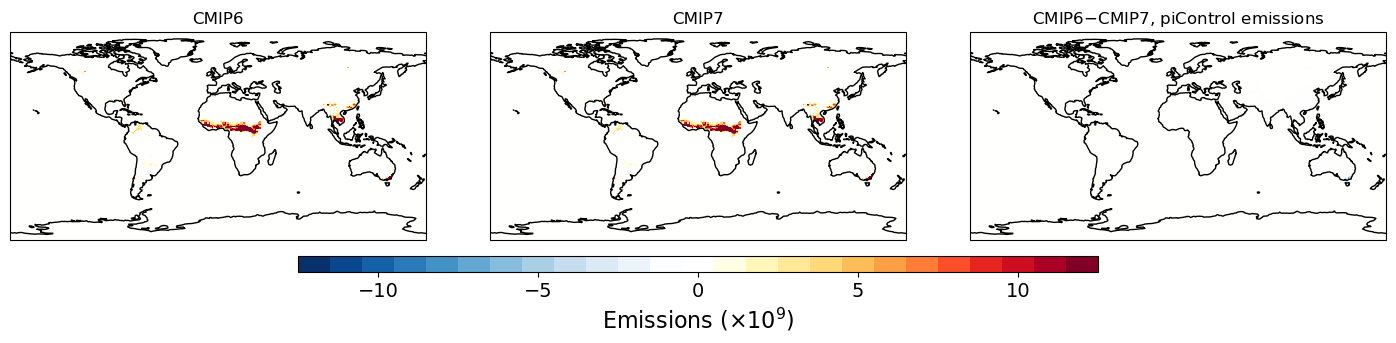

In [64]:
fig = plt.figure(figsize=(16,16))

ci = 1 ; cmin=-12 ; cmax=12

monplot=0

cmip6_pi_plot = cmip6_pi_mon.isel(month=monplot)/1e9
cmip7_pi_plot = cmip7_pi_mon.isel(month=monplot)/1e9

ax = plot_map( fig, cmip6_pi_plot, 2, -24, 24,'CMIP6',0.02,0.32,0.8,0.93)
ax = plot_map( fig, cmip7_pi_plot, 2, -24, 24,'CMIP7',0.32,0.62,0.8,0.93)
ax = plot_map( fig, (cmip6_pi_plot - cmip7_pi_plot), ci, cmin, cmax, 'CMIP6$-$CMIP7, piControl emissions',
              0.62,0.92,0.8,0.93)

ax = cbars.plotcolorbar(fig, ci, cmin, cmax, 'Emissions ($\\times$10$^{9}$)',0.22,0.72,0.78,0.79)

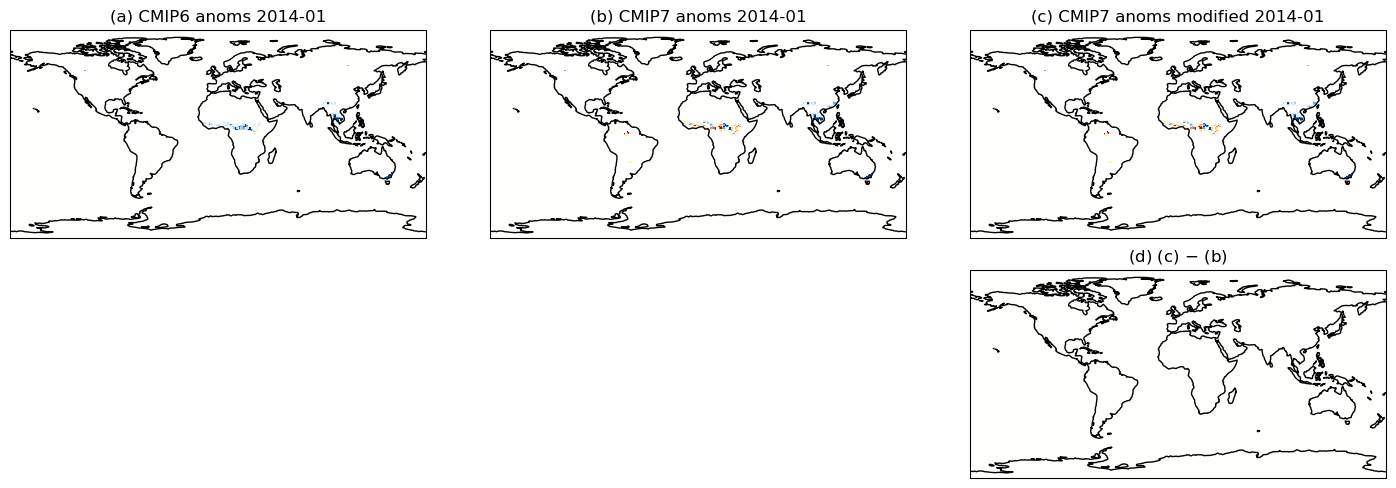

In [65]:
fig = plt.figure(figsize=(16,16))

yearplot=2014
monthplot=1

cmip6_plot = cmip6_hist_anoms.sel( time = ((cmip6_hist_anoms.time.dt.year == yearplot) & (cmip6_hist_anoms.time.dt.month == monthplot))).isel(time=0)
cmip7_plot = cmip7_hist_anoms.sel( time = ((cmip7_hist_anoms.time.dt.year == yearplot) & (cmip7_hist_anoms.time.dt.month == monthplot))).isel(time=0)
newdat_plot = newdat_anoms.sel( time = ((newdat_anoms.time.dt.year == yearplot) & (newdat_anoms.time.dt.month == monthplot))).isel(time=0).emiss

ax = plot_map(fig, cmip6_plot / 1e9, 2, -24, 24, '(a) CMIP6 anoms '+str(yearplot)+'-'+str(monthplot).zfill(2),0.02,0.32,0.8,0.93)

ax = plot_map(fig, cmip7_plot / 1e9, 2, -24, 24, '(b) CMIP7 anoms '+str(yearplot)+'-'+str(monthplot).zfill(2),0.32,0.62,0.8,0.93)


ax = plot_map(fig, newdat_plot / 1e9, 2, -24, 24, '(c) CMIP7 anoms modified '+str(yearplot)+'-'+str(monthplot).zfill(2),0.62,0.92,0.8,0.93)

ax = plot_map(fig, (newdat_plot - cmip7_plot) / 1e9, 2, -24, 24, '(d) (c) $-$ (b)', 0.62,0.92,0.65,0.78)